In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from astropy.io import fits
import time

### Load and examine SST data

Keep in mind now it has time-coordinate too. 

In [2]:
import os

In [3]:
test = fits.open('/mnt/c/Users/ivanz/OneDrive/Data/Ivan_Rahul_data_exchange/nb_8542_2019-05-06T08_33_15_scans=0-170_stokes_corrected_ALIGNED_sp_2pix_binned.fits')

In [4]:
test.info()


Filename: /mnt/c/Users/ivanz/OneDrive/Data/Ivan_Rahul_data_exchange/nb_8542_2019-05-06T08_33_15_scans=0-170_stokes_corrected_ALIGNED_sp_2pix_binned.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   (17, 4, 558, 535, 171)   float64   


In [ ]:
oneslice = test[0].data[0, :, :,:,:]
oneslice.shape


(535, 558, 4, 17)

In [7]:
# save oneslice to a fits file
oneslice = oneslice.astype(np.float32)
hdu = fits.PrimaryHDU(oneslice)
hdu.writeto('oneslice.fits', overwrite=True)

In [5]:
wave = fits.open("/mnt/c/Users/ivanz/OneDrive/Data/Ivan_Rahul_data_exchange/wav_8542.fits")[0].data

In [6]:
print(wave)

[-0.7   -0.575 -0.45  -0.375 -0.3   -0.225 -0.15  -0.075  0.     0.075
  0.15   0.225  0.3    0.375  0.45   0.575  0.7  ]


In [11]:
cube_test = np.copy(test[0].data[0,:,:,0,:])

KeyboardInterrupt: 

In [ ]:
cube_test.shape

(535, 558, 17)

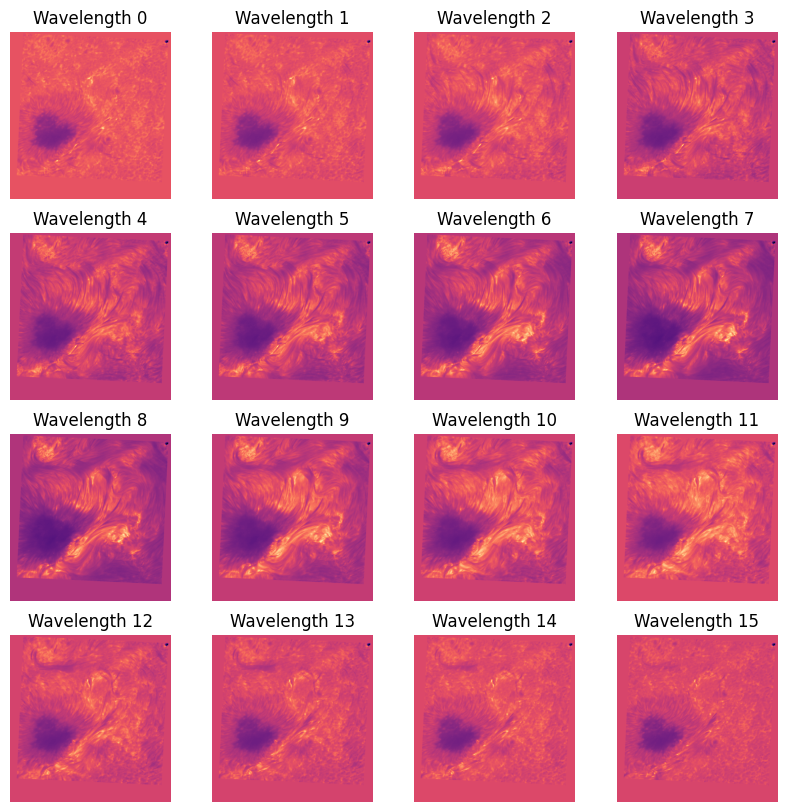

In [ ]:
# Plot first 16 wavelenghts in a 4x4 grid: 

plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(cube_test[:,:,i].T, origin='lower', cmap='magma')
    plt.title(f'Wavelength {i}')
    plt.axis('off')


In [ ]:
sst_trippel_f = fits.open('~/data/scratch/scan1.spt.lr0050.lb1.xb1.yb1.demod.xtc.si.ofs.fits')

In [ ]:
sst_trippel_f.info()

Filename: /home/milic/data/scratch/scan1.spt.lr0050.lb1.xb1.yb1.demod.xtc.si.ofs.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      11   (1403, 967, 4, 584)   float32   


In [ ]:
ll = fits.open('~/data/scratch/wavelength.fits')[0].data

In [ ]:
ll.shape

(967,)

In [ ]:
sst_trippel_1_data = sst_trippel_f[0].data

In [ ]:
sst_trippel_1_data.shape

(584, 4, 967, 1403)

In [ ]:
sst_trippel_1_data = sst_trippel_1_data.transpose(3,0,1,2)

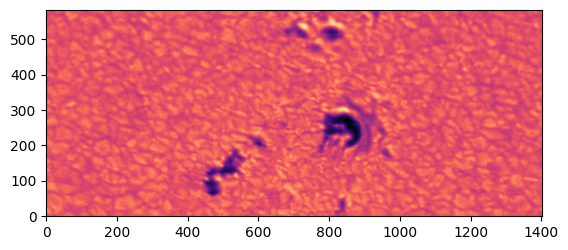

In [ ]:
plt.imshow(sst_trippel_1_data[:,:,0,100].T, origin='lower', cmap='magma')

In [ ]:
mean_spectrum = np.mean(sst_trippel_1_data, axis=(0,1))

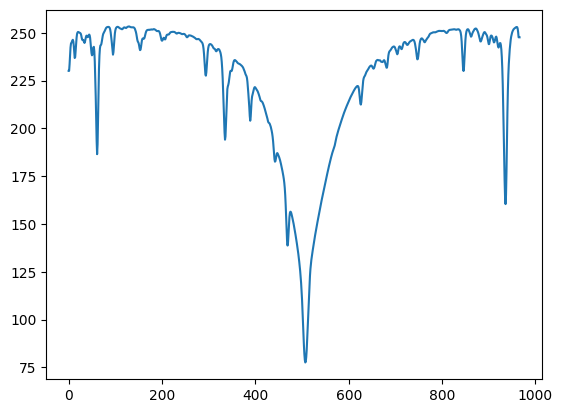

In [ ]:
plt.plot(mean_spectrum[0,:], label='Stokes I')

In [ ]:
I_qs = np.mean(sst_trippel_1_data[:200,:,0,790:810])
print (I_qs )

254.50792


In [ ]:
sst_trippel_1_data /= I_qs

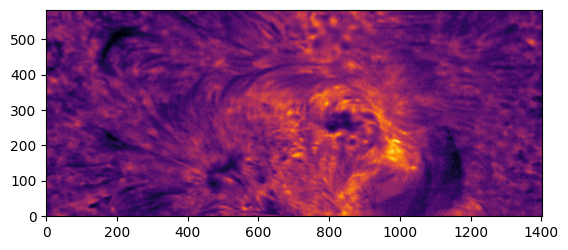

In [ ]:
plt.imshow(sst_trippel_1_data[:,:,0,500].T, origin='lower', cmap='inferno')

In [3]:
# Define a function to somewhat crop the data and pack it with wavelength
def reduce(path, wavelength_file):
    
    import os
    from tqdm import tqdm
    
    # Load wavelength data first and close file immediately
    with fits.open(wavelength_file) as wf:
        ll = np.copy(wf[0].data[:800])
    
    # Open data file with context manager to ensure it's closed
    with fits.open(path) as f:
        NY, NStokes, NWavelengths, NX = f[0].data.shape
        
        print("info::old shape is: ", f[0].data.shape)
        
        data_mini = np.zeros([NY,2,800, NX-200])
        
        print("info::new shape is:", data_mini.shape)
        
        for i in tqdm(range(NY)):
            temp = f[0].data[i,:,:800,100:-100]
            
            #print(temp.shape)
            data_mini[i,0,:,:] = temp[0,:,:]
            data_mini[i,1,:,:] = temp[3,:,:]
            del(temp)
    
    data_mini = data_mini.transpose(3,0,1,2)  # Reorder to (NX, NY, 2, 800)
    data_mini = data_mini.astype(np.float32)  # Convert to float32 for smaller file size
    
    kek = fits.PrimaryHDU(data_mini)
    but = fits.ImageHDU(ll)
    lol = fits.HDUList([kek, but])
    filename = os.path.basename(path).replace('.fits', '_reduced.fits')
    lol.writeto(filename, overwrite=True)

In [4]:
reduce('~/data/scratch/scan3.spt.lr0050.lb1.xb1.yb1.demod.xtc.si.ofs.fits', '~/data/scratch/wavelength.fits')

info::old shape is:  (673, 4, 967, 1404)
info::new shape is: (673, 2, 800, 1204)


  0%|          | 0/673 [00:00<?, ?it/s]

100%|██████████| 673/673 [00:29<00:00, 22.74it/s]


: 

In [8]:
test = fits.open('scan2.spt.lr0050.lb1.xb1.yb1.demod.xtc.si.ofs_reduced.fits')

In [6]:
test[0].data.shape

(1203, 584, 2, 800)

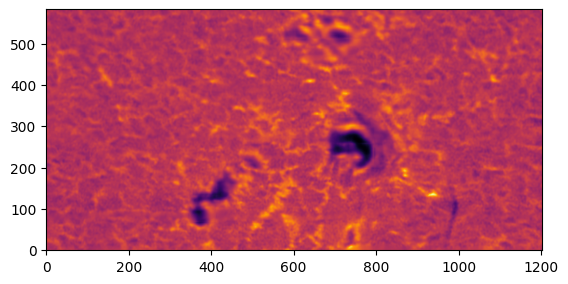

In [7]:
plt.imshow(test[0].data[:,:,0,480].T, origin='lower', cmap='inferno')